<a href="https://colab.research.google.com/github/mhh338/my_1st_repo/blob/main/02%2CML%20Work/ML%20Projects/02%2CNeural%20Network%20Projects/Proj_05(a)_CGCNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project - 5 Crystal Graph Convolution Neural Network Model

Three sections:



1.   Data loading & analysis
2.   Model construction
3.   Model training & evaluation





In [1]:
!python -c "import torch; print(torch.version.cuda)"
!python -c "import torch; print(torch.__version__)"

12.1
2.3.0+cu121


In [2]:
# # Installing required packages
# # To ensure compatibility with PyTorch Geometric's pre-compiled wheels for CUDA 12.x in Colab,
# # it's often necessary to install a specific, known-working PyTorch version.
# # We will install PyTorch 2.3.0 with CUDA 12.1 (which works with Colab's CUDA 12.8 drivers).
# !pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121

# # Install torch-scatter and torch-sparse (these will likely install numpy 2.x and scipy 1.18.0 initially)
# !pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.3.0+cu121.html --force-reinstall

# # Install other dependencies like matminer, pymatgen, ase
# !pip install matminer pymatgen ase

# # Fix for numpy/scipy incompatibility: Forcefully downgrade numpy and scipy LAST
# # This addresses the ImportError: cannot import name '_center' from 'numpy._core.umath'
# # by ensuring that numpy 1.x and a compatible scipy version are the final installed versions.
# # We'll use scipy==1.17.0 as it's the minimum required by pymatgen and is compatible with numpy 1.x.
# !pip install numpy==1.26.4 scipy==1.17.0 --force-reinstall

In [3]:
# Importing the required libraries
import random
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch_scatter
from torch.utils.data import DataLoader, random_split
from new_utils2 import MaterialsDataset, collate_fn, plot_sample
# Gather files bulk_mod_dataset.json, new_utils2.py

# **1,  Data Loading & Analysis**

In [4]:
# Setting random seed to ensure consistent results
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

Loading The Dataset

In [5]:
# Converting dataset from .json to pandas dataframe
df = pd.read_json("/content/bulk_mod_dataset.json")
df.head()

,positions,numbers,cell,y
0,"[[0.0, 0.0, 0.0], [1.377288865288202, 1.578712...","[20, 32, 32, 47, 47]","[[4.10744499, 0.0, -1.51280847], [-0.557180799...",1.447158
1,"[[3.14048493, 1.0930040075, 1.641013984999999]...","[12, 12, 32, 32, 56]","[[4.3923949, 0.0, -1.67384558], [-0.63786592, ...",1.518514
2,"[[2.068845188153371, 2.406272406310857, -0.458...","[14, 14, 29, 29, 38]","[[3.90722079, 0.0, -1.5130028100000001], [-0.5...",1.740363
3,"[[2.064280815, 0.0, 2.064280815], [0.0, 2.0642...","[46, 46, 46, 66]","[[4.12856163, 0.0, 0.0], [0.0, 4.12856163, 0.0...",1.707570
4,"[[3.0963526175, 1.0689416025, 1.53602403], [0....","[12, 12, 14, 14, 56]","[[4.35381093, 0.0, -1.68353618], [-0.65099154,...",1.602060


Information About Unit Cell Of Crystalline Structure

In [6]:
# Positions of the atoms
df.iloc[0, 0]

[[0.0, 0.0, 0.0],
 [1.377288865288202, 1.578712707985256, 3.739494024229549],
 [2.165900694711798, 2.482656352014743, -0.45182781422954904],
 [2.9377512275, 1.0133149475, 1.6438331050000001],
 [0.6054383325, 3.0480541125, 1.6438331050000001]]

In [7]:
# Atomic numbers of atoms
df.iloc[0, 1]

[20, 32, 32, 47, 47]

In [8]:
# Lattice vectors of the crystal
df.iloc[0, 2]

[[4.10744499, 0.0, -1.51280847],
 [-0.5571807999999999, 4.06947833, -1.51280847],
 [-0.00707463, -0.00810927, 6.31328315]]

Converting The Dataset To Graph

In [9]:
# Loading the dataset as a MaterialDataset object from utils.py script
dataset = MaterialsDataset(
    filename = "bulk_mod_dataset.json",
    cutoff = 4, # cutoff radius is the maximum distance within which two atoms are considered neighbors (Å).
    num_gaussians = 40 # number of gaussians in edge embedding
)

The 'num_gaussians' means CGCNN converts the cutoff = 4 into 40 gaussians centers, i.e., 40 gaussians peaks and every peak is centered at 0.1Å.

Lets say, a bond distance is 2.36 Å so the instead of storing this number directly the edge stores the whole feature of gaussians centers, like,

[0.00
 0.01
 0.05
 0.25
 0.73
 0.96
 0.81
 0.43
 ...
]

The equation of gaussian is,

$$G = exp(-\frac{(d-u)^2}{\sigma^2})$$

where,

d = actual distance

u = center of gaussian

σ = width of the gaussian peak

Now, for example, we have the distance 2.34Å, and the centers of gaussians (the edge feature),

[0.0

0.1

0.2

...

2.0

2.1

2.2

2.3

2.4

...

4.0]

so the strongest response will be of the center 2.3 as the distance is closest to it as compared to others, so according to equation,

$$(d - u)=2.34-2.3=0.04$$
<br>$If~\sigma=0.3$<br>
$$G(d) = 0.982~or~98.2\%$$






In [10]:
# Total number of graph structures in the dataset
len(dataset)

10987

In [11]:
# Dataset.data as a dataframe
pd.DataFrame(dataset.data).head(9)

,positions,numbers,cell,y,atoms,edge_src,edge_dst,edge_len
0,"[[0.0, 0.0, 0.0], [1.3772888652882023, 1.57871...","[20, 32, 32, 47, 47]","[[4.10744499, 0.0, -1.51280847], [-0.5571808, ...",1.447158,"(Atom('Ca', [0.0, 0.0, 0.0], index=0), Atom('G...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 4, 1, 2, 4, 3, 2, 3, 1, 1, 4, 3, 3, 2, 1, ...","[3.325485944727173, 3.515590521145633, 3.32548..."
1,"[[3.1404849300000004, 1.0930040075, 1.64101398...","[12, 12, 32, 32, 56]","[[4.3923949, 0.0, -1.67384558], [-0.63786592, ...",1.518514,"(Atom('Mg', [3.1404849300000004, 1.0930040075,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...","[1, 2, 1, 4, 4, 3, 2, 1, 1, 3, 4, 4, 4, 3, 2, ...","[3.323769847460169, 2.8070551062312896, 3.3237..."
2,"[[2.068845188153371, 2.406272406310857, -0.458...","[14, 14, 29, 29, 38]","[[3.90722079, 0.0, -1.51300281], [-0.58588384,...",1.740363,"(Atom('Si', [2.068845188153371, 2.406272406310...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1, 4, 3, 1, 1, 2, 3, 4, 4, 2, 4, 4, 1, 1, 3, ...","[2.4520156311206254, 3.2063797451756417, 2.445..."
3,"[[2.064280815, 0.0, 2.064280815], [0.0, 2.0642...","[46, 46, 46, 66]","[[4.12856163, 0.0, 0.0], [0.0, 4.12856163, 0.0...",1.707570,"(Atom('Pd', [2.064280815, 0.0, 2.064280815], i...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...","[2, 1, 2, 1, 1, 2, 3, 1, 3, 3, 3, 2, 0, 2, 3, ...","[2.919333925119586, 2.919333925119586, 2.91933..."
4,"[[3.0963526175, 1.0689416025, 1.53602403], [0....","[12, 12, 14, 14, 56]","[[4.35381093, 0.0, -1.68353618], [-0.65099154,...",1.602060,"(Atom('Mg', [3.0963526175, 1.0689416025, 1.536...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...","[1, 2, 1, 4, 4, 3, 2, 1, 1, 3, 4, 4, 4, 3, 2, ...","[3.300754737246957, 2.7870249562843394, 3.3007..."
5,"[[0.0, 0.0, 0.0], [1.41205261, 1.41205261, 2.0...","[13, 22]","[[2.82410522, 0.0, 0.0], [0.0, 2.82410522, 0.0...",1.845098,"(Atom('Al', [0.0, 0.0, 0.0], index=0), Atom('T...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, ...","[3.993887903692653, 2.82410522, 3.993887903692..."
6,"[[1.74050602, 1.74050602, 1.74050602], [0.0, 0...","[46, 68]","[[3.48101204, 0.0, 0.0], [0.0, 3.48101204, 0.0...",1.491362,"(Atom('Pd', [1.74050602, 1.74050602, 1.7405060...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, ...","[3.0146448575194924, 3.48101204, 3.01464485751..."
7,"[[0.0, 0.0, 0.0], [0.0, 0.0, 2.87508272], [-2....","[46, 46, 52, 52]","[[4.2119145, 0.0, 0.0], [-2.10595725, 3.647624...",1.301030,"(Atom('Pd', [0.0, 0.0, 0.0], index=0), Atom('P...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, ...","[3, 1, 1, 2, 2, 2, 3, 3, 2, 2, 3, 2, 0, 3, 0, ...","[2.824877544757287, 2.87508272, 2.87508272, 2...."
8,"[[0.0, 0.0, 1.749162845], [3.2119638054529718,...","[14, 14, 14, 25, 25, 25, 41, 41, 41]","[[6.42392755, 0.0, 0.0], [-3.21196378, 5.56328...",2.021189,"(Atom('Si', [0.0, 0.0, 1.749162845], index=0),...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[5, 3, 0, 0, 6, 8, 4, 4, 6, 5, 3, 8, 7, 7, 2, ...","[2.351975016099561, 2.35197501574303, 3.498325..."


In [12]:
# In a graph like representation, having edge features & node features.
dataset[0] # 1st graph object

Data(node_feat=tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

Take A Look At The Data

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_20624/3259433388.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax.set(xlabel="log10(G$_\mathrm{VRH}$)", ylabel="Number of examples")


[Text(0.5, 0, 'log10(G$_\\mathrm{VRH}$)'), Text(0, 0.5, 'Number of examples')]

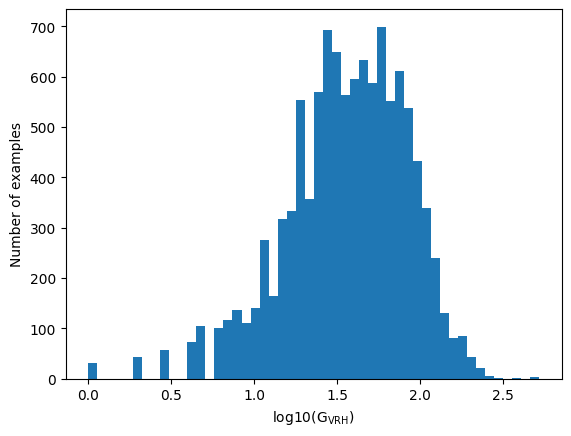

In [13]:
# Plotting a histogram of the targeted values to see the distribution of data.
values = [x.target[0] for x in dataset]

fig, ax = plt.subplots()
ax.hist(values, bins=50)
ax.set(xlabel="log10(G$_\mathrm{VRH}$)", ylabel="Number of examples")

Each sample has the following information:



*   **node_feat:** The node features as a (N, num_node_features) tensor.
*   **edge_feat:** The edge features as a (M, num_edge_features) tensor.
*   **edge_src:** The index of the central node for each edge.
*   **edge_dist:** The index of destination node for each edge.
*   **target:** The target property to learn.
*   **atoms:** An ase atoms object, representing the structure.

Here, N & M are the number of nodes and features respectively.



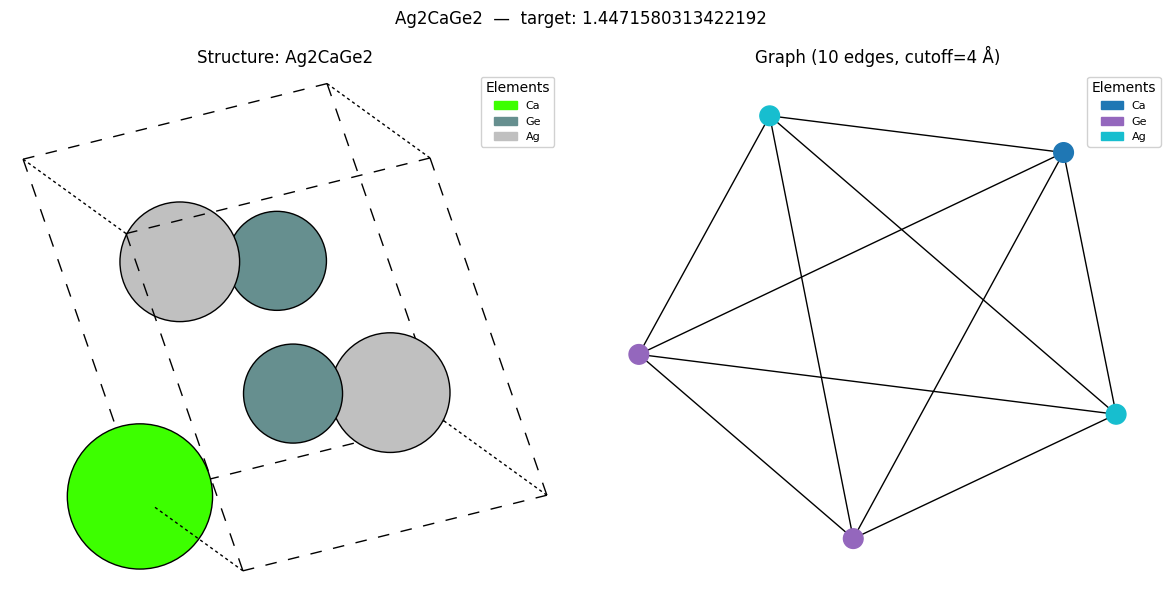

Formula         : Ag2CaGe2
Number of atoms : 5
Number of edges : 58
Target property : 1.4471580313422192


In [14]:
sample = dataset[0]
plot_sample(dataset, idx=0)

Node Features

In [15]:
print("Node features:\n", sample.node_feat)
print("Shape of the node feature matrix: ", sample.node_feat.shape)

Node features:
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

This tells us there are 5 atoms in the structure and each node has 100 features. The node features are just a hot encoding of the atom type, if we loaak at the first atom it has 1 at the 19th index and zeros elsewhere, which means it is the 20th element in the periodic table i.e., calcium.

In [16]:
# 1st atom Ca
print(sample.node_feat[0])
print("Index-19: ", sample.node_feat[0][19])


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Index-19:  tensor(1.)


In [17]:
# 2nd atom Ge
print(sample.node_feat[1])
print("Index-31: ", sample.node_feat[1][31])

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Index-31:  tensor(1.)


In [18]:
# 3rd atom Ag
print(sample.node_feat[3])
print("Index-46: ", sample.node_feat[3][46])

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Index-46:  tensor(1.)


Edge Features

In [19]:
print("Edge features:\n", sample.edge_feat)
print("Shape of edge feature matrix: ", sample.edge_feat.shape)

Edge features:
 tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 8.0156e-10, 3.1227e-14,
         1.6464e-19],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 6.0234e-04, 9.5584e-07,
         2.0528e-10],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 8.0156e-10, 3.1227e-14,
         1.6464e-19],
        ...,
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 6.0234e-04, 9.5584e-07,
         2.0528e-10],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 6.1006e-21, 2.6618e-27,
         1.5717e-34]])
Shape of edge feature matrix:  torch.Size([58, 40])


Here we can see there are 58 edges in the structure and 40 features per edge.

In [20]:
# 1st edge
sample.edge_feat[0]

tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.7147e-39,
        1.5296e-31, 1.1663e-24, 1.2036e-18, 1.6810e-13, 3.1773e-09, 8.1274e-06,
        2.8136e-03, 1.3182e-01, 8.3582e-01, 7.1722e-01, 8.3293e-02, 1.3091e-03,
        2.7845e-06, 8.0156e-10, 3.1227e-14, 1.6464e-19])

The edge embedding is the bond length projected onto a basis of 40 equally spaced gaussians (discussed in the previous cells).

Visualizing for 10 gaussian basis function for clarity.

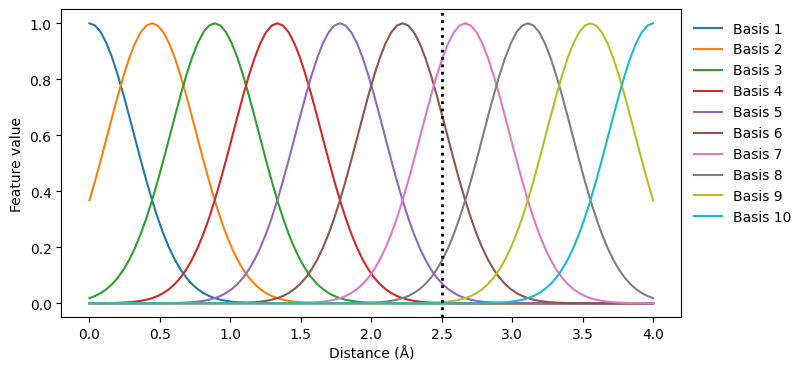

In [21]:
num_gaussians = 10
fig, ax = plt.subplots(figsize=(8,4))
dists = np.linspace(0, 4, 100)
centres = np.linspace(0, 4, num_gaussians)
edge_feat = np.exp(-((dists[:, None] - centres) ** 2) / (centres[1] - centres[0]) ** 2)
ax.plot(dists, edge_feat, label=[f"Basis {i+1}" for i in range(num_gaussians)])
ax.axvline(x=2.5, color="black", linestyle=":", linewidth=2)
ax.set(xlabel="Distance (Å)", ylabel= "Feature value")
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", frameon=False)

For understanding, lets say for the bond length 2.5Å shwon by the black doted line, the value of the each basis function at 2.5Å is used to form the embedding. In this case, the first 3 functions have the value very close to zero at 2.5Å and the other having high values.

Converting the gaussian centres to embedding vector

In [22]:
# Gaussian equation discussed in aboe cells.
edge_feat = np.exp(-((2.5 - centres) ** 2) / (centres[1] - centres[0]) ** 2).round(3)
print("Edge feature of bond length 2.5Å:\n", edge_feat)

Edge feature of bond length 2.5Å:
 [0.    0.    0.    0.001 0.071 0.677 0.869 0.151 0.004 0.   ]


Lets now look which atom forms how many bonds and to which atoms it is connected to.

In [23]:
# Number of bonds of each atom
sample.edge_src

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4])

The numbers correspond to the index of the atoms in the structure, as there are 5 atoms in our structure so the indices are from 0 to 4.

The first 15 numbers are zero, indicating that the first atom in the structure has 15 bonds.

In [24]:
# Destination atoms
sample.edge_dst

tensor([2, 4, 1, 2, 4, 3, 2, 3, 1, 1, 4, 3, 3, 2, 1, 4, 4, 3, 4, 3, 2, 0, 0, 0,
        0, 4, 0, 4, 0, 0, 3, 3, 0, 1, 0, 0, 4, 4, 1, 0, 4, 2, 4, 2, 1, 0, 2, 3,
        3, 2, 1, 0, 0, 0, 3, 0, 1, 3])

The numbers showing the destination atoms of each edge, say, for the first atom it has 15 bonds, so, 1st bond with 2nd-indexed atom, 2nd bond with 4th-indexed atom, so on.

Here we can see that there can be more than one bond to same destination atom, this is because of periodic boundary conditions, some of these bonds will be bonded to atoms in the adjacent unit cells.

**Splitting The Data For Training, Testing & Validation**

In [25]:
# 80% of data for training, 10% for validation and 10% for testing.
train_set, valid_set, test_set = random_split(dataset, [0.8, 0.1, 0.1])

print("Number of training examples: ", len(train_set))
print("Number of validation examples: ", len(valid_set))
print("Number of testing examples: ", len(test_set))

Number of training examples:  8790
Number of validation examples:  1099
Number of testing examples:  1098


Setting Up The Batches

In [26]:
# Setting up mini batches for training, grouping multiple graphs into a batch.
BATCH_SIZE = 32 # Hyperparameter

train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True,
)

valid_loader = DataLoader(
    valid_set, batch_size=BATCH_SIZE, collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_set, batch_size=BATCH_SIZE, collate_fn=collate_fn,
)

**Exploring Batch Data Format**

Each batch has following information:


*   **node_feat:** The node features as a (N, n_node_feat) tensor.

*   **edge_feat:** The edge features as a (M, n_edge_feat) tensor.

*   **edge_src:** The index of the central node for each edge.

*   **edge_dst:** The index of the destination node for each edge.

*   **target:** The target property to learn, as a (G, 1) tensor.

*   **batch:** The graph to which each node belongs as a (N, 1) tensor.

Here N and M are the total number of atoms/nodes and edges in a batch not in a given structure, whereas, G is the total number of graphs (structure) in a batch.





Let's have a look at the node features for the first batch of the test set.

In [27]:
batch = next(iter(test_loader))
batch.node_feat.shape

torch.Size([302, 100])

We can see that in the first batch we have 302 nodes and the number of node features i.e., n_node_feat, remains same i.e., 100.

The number of edges in this batch will be,

In [28]:
batch.edge_feat.shape

torch.Size([5778, 40])

As we are handling multiple graphs simultaneously, the **batch.batch** attribute is essential to know which which graph each atom belongs to.

In [29]:
batch.batch[:]

tensor([ 0,  0,  0,  0,  0,  1,  1,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,
         3,  3,  3,  3,  3,  4,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  6,
         7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
         7,  7,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9, 10, 10, 10, 10, 11, 11,
        11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13,
        13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15,
        15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
        15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
        15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16,
        17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18,
        19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 21, 21, 21, 21,
        21, 21, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
        23, 23, 23, 23, 23, 23, 23, 23, 

The first five nodes in the **batch.node_feat** array i.e., in the first batch, correspond to 1st structure, while the next two nodes belongs to 2nd structure, so on.

# **2, Model Construction**

## **Graph Convolution**

We have to compute following steps,

$$m_{i}^{t} = v_{i}^{t}~\bigoplus~v_{j}^{t}~\bigoplus~e_{ij}^{t}$$

where $i$ and $j$ are the indices of the central and neighbouring atoms respectively, and $m_{i}$ is a one combined long **message** vector for that specific bond, $v^{t}$ and $e^{t}$ are the node and edge embeddings for the convolution $t$.

The update function is performed as,

$$z_{i}^{t}=v_{i}^{t}+∑_{j\in\mathcal{N}}~\sigma~(W_{f}^{t}~m_{i}^{t}+b_{f}^{t})~⨀~g~(W_{s}^{t}~m_{i}^{t}+b_{s}^{t})$$

$$v_{i}^{t+1}=g(z_{i}^{t})$$

where the $\sigma$ and $g$ are the **sigmoid** and **softplus** functions respectively, and $W$ and $b$ are the **weight** and **bias** parameters.

#### **Softplus Activation Function:**

**Softplus** function is the smooth version of the **ReLU** function.

$$softplus(x)=ln(1+e^x)$$

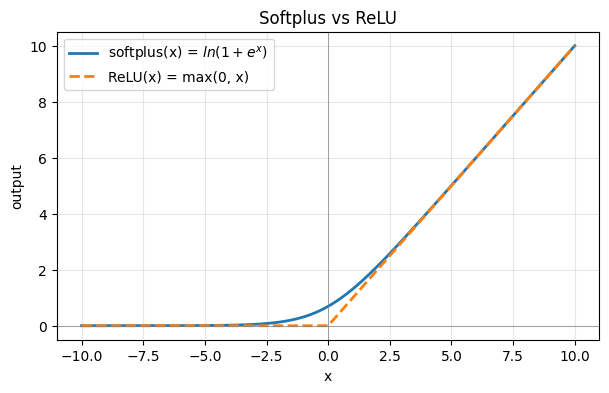

In [30]:
# Plotting softplus function
import numpy as np
import matplotlib.pyplot as plt

# softplus: ln(1 + e^x)
def softplus(x):
    return np.log1p(np.exp(x))  # log1p(e^x) is more numerically stable than log(1+e^x)

# relu, for comparison
def relu(x):
    return np.maximum(0, x)

x = np.linspace(-10, 10, 500)

plt.figure(figsize=(7, 4))
plt.plot(x, softplus(x), label="softplus(x) = $ln(1 + e^x)$", linewidth=2)
plt.plot(x, relu(x), label="ReLU(x) = max(0, x)", linestyle="--", linewidth=2)

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.title("Softplus vs ReLU")
plt.xlabel("x")
plt.ylabel("output")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Now implementing the convolution layer

In [31]:
# This defines the graph convolution layer where node features are updated based on messages from their neighbors.

class GraphConvolution(nn.Module):

  # Initialization function
  def __init__(self, node_feat_dim, edge_feat_dim):
    # 'node_feat_dim' : number of node features
    # 'edge_feat_dim' : number of edge features

    super().__init__()

    # Linear layer used for the gated MLP
    self.lin1 = nn.Linear(
        2 * node_feat_dim + edge_feat_dim,
        2 * node_feat_dim
    ) # nn.Linear(input, output) --> input : 2 * 100 + 40, output : 2 * 100

    # Batch normalization layers
    self.bn1 = nn.BatchNorm1d(2 * node_feat_dim)
    self.bn2 = nn.BatchNorm1d(node_feat_dim)

  # Foward propagation
  def forward(self, node_feat, edge_feat, edge_src, edge_dst):
    # 'node_feat' : node features
    # 'edge_feat' : edge features
    # 'edge_src' : indices of the central nodes for the edges
    # 'edge_dst' : indices of the destination nodes for the edges

    # Concatenating node and edge features along columns
    m = torch.cat([node_feat[edge_src], node_feat[edge_dst], edge_feat], dim=1)
    # Dimension of 'm': [num_edge, 2 * node_embed + edge_embed]

    # Gated MLP
    z = self.lin1(m) # [num_edges, 2 * node_embed]
    z = self.bn1(z) # [num_edges, 2 * node_embed]
    z1, z2, = z.chunk(2, dim=1) # Splitting the z matrix into 2 matrix containing half the number of columns, dim will be z1 (for the gate) : [num_edges, node_embed], z2 (for the content) : [num_edges, node_embed]
    z1 = nn.Sigmoid()(z1)
    z2 = nn.Softplus()(z2)
    z = z1 * z2 # Element-wise multiplication, [num_edges, node_embed].
    # This is the classic gating mechanism where, each dimension of the content gets scaled by how "open" its corresponding gate is.

    # Pooling the features,
    z = torch_scatter.scatter_add(z, edge_src, out=torch.zeros_like(node_feat), dim=0) # [num_nodes, node_embed]

    # Passing through normalization layer
    return nn.Softplus()(self.bn2(z) + node_feat)



## **Full Graph Network Architecture**

Now we have the convolution, we can construct the CGCNN model.

The components of CGCNN will be,


*   An MLP that transforms the one-hot encoded node features to node embedding. The dimensionality of the node embedding is controlled by **node_hidden_dim**.

*   The pooling of the node features to obtain the crystal features $u_c$, calculated as,

$$u_c=\sum_{i\in\mathcal{G}}~\frac{v_{i}^{T}}{|\mathcal{G}|}$$

This equation is the pooling step — where CGCNN goes from "one feature vector per atom" to "one feature vector for the whole crystal."

This is just the average (mean) of all the atoms' final feature vectors — summing every atom's vector, then dividing by how many atoms there are. It's mathematically identical to writing:

$$u_c=\frac{1}{|\mathcal{G}|}\sum_{i\in\mathcal{G}}~{v_{i}^{T}}$$

which might be recognized as the standard formula for a mean.

where, $v_{i}^{T}$ — atom $i's$ feature vector, but taken at layer $T$ - meaning after all the graph convolution layers have finished, here $T$ is the final layer, and $\mathcal{G}$ — this denotes the crystal/graph itself, treated as the set of all atoms belonging to it.


*   An MLP that takes $u_c$ and outputs the target property. In CGCNN this consists of a fully-connected layer with soft-plus activation function.

Now implementing the CGCNN model, the number of convolutions can be controlled using the $num_graph_conv_layers$ parameter.

In [62]:
# CGCNN model architecture
class CGCNN(nn.Module):
  def __init__(
    self,
    node_feat_dim,
    edge_feat_dim,
    node_hidden_dim=64,
    num_graph_conv_layers=9,
    fc_feat_dim=128
  ):
    """
    Parameters:
    node_feat_dim (int) : Number of node features from one-hot encoding.
    edge_feat_dim (int) : Number of bond features.
    node_hidden_dim (int) : The number of features in node embedding.
    num_graph_conv_layers (int) : Number of convolution layers (hyperparameter).
    fc_feat_dim (int) : Number of hidden features after pooling.
    """

    super().__init__()

    # Dense layer to transform one-hot encoded node features to embedding
    self.embedding = nn.Linear(node_feat_dim, node_hidden_dim)

    # Setting up the convolutions
    convs = []
    for _ in range(num_graph_conv_layers):
      convs.append(GraphConvolution(node_feat_dim=node_hidden_dim, edge_feat_dim=edge_feat_dim))
    self.convs = nn.ModuleList(convs)

    # Dense layer to turn final node embeddings to the crystal features
    self.conv_to_fc = nn.Sequential(
        nn.Linear(node_hidden_dim, fc_feat_dim), nn.Softplus()
    )

    # Dense layer to get the final target value
    self.fc_out = nn.Linear(fc_feat_dim, 1)

  def forward(self, batch):
    """
    Predicting a target property in a given batch of data.

    Parameters:
    batch : Batch, the data to pass through the network.
    """

    # Getting initial node embedding
    node_feat = self.embedding(batch.node_feat)
    # Converts every atom's one-hot vector (batch.node_feat, shape [total_atoms_in_batch, node_feat_dim]) into its dense embedding (shape [total_atoms_in_batch, node_hidden_dim]).

    # Apply convolutions
    for conv_func in self.convs:
      node_feat = conv_func(node_feat, batch.edge_feat, batch.edge_src, batch.edge_dst)
    # Loops through the 3 stacked GraphConvolution layers, updating node_feat each time.

    # Pooling node vectors
    crys_feat = torch_scatter.scatter_mean(node_feat, batch.batch, dim=0)
    #  Input: [total_atoms_in_batch, node_hidden_dim], Output: [num_crystals_in_batch, node_hidden_dim] — one averaged vector per crystal.

    # Passing pooled vector through FC layer with activation function
    crys_feat = self.conv_to_fc(crys_feat)
    # Passes each crystal's pooled vector through the linear+softplus block, widening it to fc_feat_dim (128) and adding nonlinearity.


    # Passing crystal features through final fully-connected layer
    return self.fc_out(crys_feat)
    # Final linear layer collapses each crystal's 128-dim vector down to a single predicted number. Output shape: [num_crystals_in_batch, 1] — exactly one prediction per crystal in the batch


# **3, Model Training**


Next, we'll define our optimizer. This is the algorithm we will use to update the parameters of our model with respect to the loss calculated on the data, the work flow will be,

*    Passing a batch of data through the model.

*    Calculating the loss of the batch by comparing the model's predictions against the target value.

*    Calculating the gradient of each of the parameters with respect to the loss.

*    Updating each of the parameters by subtracting their gradient multiplied by a small learning rate parameter.

We use the AdamW optimiser with the default parameters to update our model.

Then, we define a criterion, PyTorch's name for a loss/cost/error function. This function will take in the model's predictions with the actual target value and then compute the loss/cost/error of the model with its current parameters.

In this case, we will use the mean squared error loss function, defined as,

$$MSE=\frac{1}{n}∑_{i=1}^{n}(y_i-\hat{y_i})^2$$

where $n$ is the number of data points, $y_i$ are the actual values and $\hat{y_i}$ are the predicted values from the model.

Creating an instance of the CGCNN model

In [61]:
NUM_NODE_FEATURES = sample.node_feat.size()[1]
NUM_EDGE_FEATURES = sample.edge_feat.size()[1]

NUM_CONVOLUTIONS = 9

model = CGCNN(
    NUM_NODE_FEATURES,
    NUM_EDGE_FEATURES,
    num_graph_conv_layers = NUM_CONVOLUTIONS
)

In [56]:
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.MSELoss()

Looking for GPU

In [57]:
# Runing the code on GPU if available otherwise remain on CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
criterion = criterion.to(device) # Calculating loss/error function.

Defining Training Loop

In [58]:
def train(model, dataloader, criterion, optimizer, device):
  epoch_loss = 0 # MSE : Mean Squared Error, used for training the model.
  epoch_mae = 0 # MAE : Mean Absolute Error = 1/N ∑_(k=1)^N |y_pred,k - y_actual,k|, used for displaying how much the predicted value is far from the actual one.

  model.train()

  for i, batch in enumerate(dataloader):
    # Moving the data onto the GPU if available
    batch.to(device)

    # Computing the output
    y_pred = model(batch)
    """Runs the forward pass — feeds the batch through the whole CGCNN model
       (embedding → 3 conv layers → pooling → FC layers) and gets back predictions,
       shape [num_crystals_in_batch, 1]. """

    loss = criterion(y_pred, batch.target) # Computing the loss
    mae = nn.L1Loss()(y_pred, batch.target)
    # Separately computes MAE for this batch, using PyTorch's built-in nn.L1Loss() (L1 loss is mean absolute error — L2 loss is for MSE).

    # Computing gradients
    optimizer.zero_grad() # Clearing previous gradients
    loss.backward() # Backpropagation,  only loss gets backpropagated — MAE was never involved in this, since it's purely for display.
    optimizer.step() # Updating model's parameters i.e., weights and biases.

    # Updating the metrics
    epoch_loss += loss.item()
    epoch_mae += mae.item()

  return epoch_loss / len(dataloader), epoch_mae / len(dataloader) # Returning averages of epoch_loss & epoch_mae.

Setting Up An Evaluation Loop

In [59]:
def evaluate(model, dataloader, criterion, device):
  epoch_loss = 0
  epoch_mae = 0

  model.eval()

  with torch.no_grad():
    for i, batch in enumerate(dataloader):
      batch.to(device)

      # Computing the output
      y_pred = model(batch)
      loss = criterion(y_pred, batch.target)
      mae = nn.L1Loss()(y_pred, batch.target)

      # Updating the metrics
      epoch_loss += loss.item()
      epoch_mae += mae.item()

  return epoch_loss / len(dataloader), epoch_mae / len(dataloader)

### **Running The Training Process**

We will train for 10 epochs, at the end of each epoch we check the validation loss, if it is better than the previous best, then we save the model.




In [38]:
# Main training block
EPOCHS = 30

best_valid_loss = float("inf")
""" Initializes a tracker for the best (lowest) validation loss seen so far,
    starting at 'inf' (infinity) so that literally any real validation loss computed in
    epoch 1 will be smaller and immediately count as an improvement. """
history = []
start_time = time.time()

for epoch in range(EPOCHS):

  train_loss, train_mae = train(model, train_loader, criterion, optimizer, device)
  # Returns the average loss and average MAE across all training batches this epoch.

  valid_loss, valid_mae = evaluate(model, valid_loader, criterion, device)
  """runs the model over the validation set (valid_loader) using 'evaluate' function
     just measuring how the model currently performs on data it wasn't trained on this epoch.
     This gives an honest signal of how well training is generalizing, not just memorizing."""

  if valid_loss < best_valid_loss:
    best_valid_loss = valid_loss
    torch.save(model.state_dict(), "elastic-model-3.pt")

  epoch_time = time.time() - start_time
  history.append({"epoch" : epoch, "epoch_time" : epoch_time, "valid_mae" : valid_mae, "train_mae" : train_mae})

  print(f"Epoch : {epoch+1:02} | Train MAE : {train_mae:8.4f} | Valid_MAE : {valid_mae:8.4f}" f" | Elapsed time : {time.strftime("%M min %S s", time.gmtime(epoch_time))}")
  # 'epoch+1' prints epochs as 1–10, not 0–9, more natural for humans, ':02' zero-padded to at least 2 digits (e.g. 01, 02, ... 10).
  # 'train_mae:8.4f' — formats the float in a field 8 characters wide, with 4 decimal places.
  # 'time.gmtime(epoch_time)' — converts the raw elapsed seconds into a 'struct_time' object representing that  duration as if it were a clock time.
  # 'time.strftime("%M min %S s", ...)' — formats that 'struct_time' into a readable string like "03 min 27 s".


Epoch : 01 | Train MAE :   0.2270 | Valid_MAE :   0.2607 | Elapsed time : 03 min 19 s
Epoch : 02 | Train MAE :   0.1638 | Valid_MAE :   0.2158 | Elapsed time : 06 min 38 s
Epoch : 03 | Train MAE :   0.1628 | Valid_MAE :   0.1747 | Elapsed time : 09 min 58 s
Epoch : 04 | Train MAE :   0.1552 | Valid_MAE :   0.1669 | Elapsed time : 13 min 22 s
Epoch : 05 | Train MAE :   0.1401 | Valid_MAE :   0.1838 | Elapsed time : 16 min 48 s
Epoch : 06 | Train MAE :   0.1322 | Valid_MAE :   0.1467 | Elapsed time : 20 min 08 s
Epoch : 07 | Train MAE :   0.1291 | Valid_MAE :   0.1527 | Elapsed time : 23 min 27 s
Epoch : 08 | Train MAE :   0.1275 | Valid_MAE :   0.1572 | Elapsed time : 26 min 47 s
Epoch : 09 | Train MAE :   0.1256 | Valid_MAE :   0.1387 | Elapsed time : 30 min 07 s
Epoch : 10 | Train MAE :   0.1281 | Valid_MAE :   0.1475 | Elapsed time : 33 min 26 s
Epoch : 11 | Train MAE :   0.1225 | Valid_MAE :   0.1193 | Elapsed time : 36 min 46 s
Epoch : 12 | Train MAE :   0.1186 | Valid_MAE :   0.12

### **Plotting The Results**

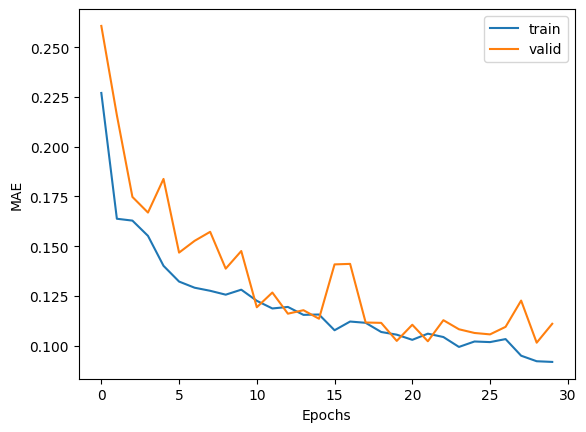

In [53]:
epochs = [x["epoch"] for x in history]
train_loss = [x["train_mae"] for x in history]
valid_loss = [x["valid_mae"] for x in history]

fig, ax = plt.subplots()
ax.plot(epochs, train_loss, label="train")
ax.plot(epochs, valid_loss, label="valid")
ax.set(xlabel="Epochs", ylabel="MAE")
plt.legend()

### **Evaluating The Model's Accuracy On The Test Set**

In [63]:
model.load_state_dict(torch.load("elastic-model-3.pt"))
test_loss, test_mae = evaluate(model, test_loader, criterion, device)
print(f"Test MAE : {test_mae:8.4f}")

Test MAE :   0.1012


### **Parity Plot**

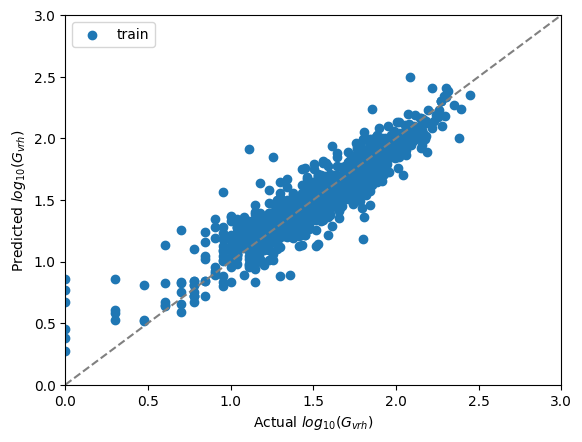

In [65]:
# On the test dataset
actual = []
predicted = []

model.eval()
with torch.no_grad():
  for i, batch in enumerate(test_loader):
    batch.to(device)
    y_pred = model(batch)
    predicted.extend(y_pred.cpu().tolist())
    actual.extend(batch.target.tolist())

fig, ax = plt.subplots()
ax.scatter(actual, predicted, label="train")
ax.plot([0, 3], [0, 3], ls = "--", c = "grey")
ax.set(ylabel="Predicted $log_{10}(G_{vrh})$", xlabel = "Actual $log_{10}(G_{vrh})$", xlim=(0, 3), ylim=(0, 3))
plt.legend()